# 03 - Modelagem supervisionada

Compara três algoritmos sob o mesmo pré-processamento, integrado ao `Pipeline` do
Scikit-learn. A ordem das etapas é deliberada: **primeiro escolher o algoritmo sem
olhar o holdout, depois medir o que acontece no ciclo seguinte.** É a diferença
entre as duas medições que produz o principal achado metodológico do projeto.

In [1]:
# ==== 1. PREPARAÇÃO ====
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.model_selection import GridSearchCV

from src.modeling import (
    FEATURES, TARGET, carregar_dataset, construir_pipeline,
    modelos_candidatos, separar_xy,
)
from src.evaluation import (
    avaliar, comparar_por_validacao_cruzada, curva_calibracao,
    desvio_de_calibracao, importancia_nativa, importancia_por_permutacao,
    importancia_shap, limiar_por_recall, matriz_confusao, particionador,
    valores_shap,
)
from src.visualization import NEGATIVO, POSITIVO, SERIE, aplicar_estilo, limpar, salvar

aplicar_estilo()
IMAGENS = ROOT / "images"
SEMENTE = 42

df = carregar_dataset()
treino = df[df["ano"] == 2023].copy()
teste = df[df["ano"] == 2024].copy()
X_treino, y_treino = separar_xy(treino, FEATURES)
X_teste, y_teste = separar_xy(teste, FEATURES)

print(f"Treino 2023: {len(treino):,} municipios | prevalencia {y_treino.mean():.1%}")
print(f"Holdout 2024: {len(teste):,} municipios | prevalencia {y_teste.mean():.1%}")
print("Features:", FEATURES)

Treino 2023: 5,302 municipios | prevalencia 18.1%
Holdout 2024: 5,352 municipios | prevalencia 43.4%
Features: ['media_portugues', 'meta_2025', 'meta_uf_2025', 'taxa_media_uf_loo', 'sigla_uf', 'regiao']


## Etapa 2 - Split temporal e tratamento de data leakage

- **Treino:** 2023. **Teste final:** 2024. O holdout não participa do ajuste nem
  da escolha dos hiperparâmetros.
- Taxa, gap, status, nível e proporções SAEB ficam fora de `X` — são o alvo, ou
  transformações dele.
- A média estadual é *leave-one-out*: o próprio município não entra na sua média.
- Imputação, padronização e one-hot vivem **dentro** do `Pipeline`, portanto são
  reajustadas em cada fold e nunca aprendem com os dados de avaliação.

In [2]:
# ==== 2. SELEÇÃO DO ALGORITMO USANDO SOMENTE 2023 ====
# Nenhuma linha de 2024 é tocada aqui: esta é a comparação que se poderia usar
# para escolher o algoritmo em um cenário real, antes de o ciclo seguinte existir.
candidatos = modelos_candidatos(com_baseline=True)
cv_2023 = comparar_por_validacao_cruzada(
    candidatos, construir_pipeline, X_treino, y_treino
)
display(cv_2023.round(4))

,modelo,roc_auc_val,roc_auc_desvio,pr_auc_val,f1_val,roc_auc_treino,gap_roc_auc
0,Random Forest,0.9960,0.0038,0.9919,0.9794,0.9994,0.0033
1,Gradient Boosting,0.9945,0.0046,0.9814,0.9801,0.9999,0.0054
2,Regressão Logística,0.9740,0.0053,0.9163,0.7957,0.9768,0.0028
3,Baseline (classe majoritária),0.5000,0.0000,0.1813,0.0000,0.5000,0.0000


**Leitura.** Dentro de 2023 os ensembles parecem imbatíveis: Random Forest chega a
**ROC-AUC 0,996** e Gradient Boosting a 0,994, contra 0,974 da Regressão Logística.
O `gap_roc_auc` é baixo em todos, então a validação cruzada **não acusa
sobreajuste**. Escolhendo pelo procedimento-padrão, levaríamos o Random Forest.

In [3]:
# ==== 3. O QUE ACONTECE NO CICLO SEGUINTE ====
holdout = []
for nome, estimador in candidatos.items():
    modelo = construir_pipeline(estimador).fit(X_treino, y_treino)
    prob = modelo.predict_proba(X_teste)[:, 1]
    holdout.append({"modelo": nome, **avaliar(y_teste, modelo.predict(X_teste), prob)})
holdout = pd.DataFrame(holdout).sort_values("roc_auc", ascending=False)

generalizacao = (
    cv_2023[["modelo", "roc_auc_val"]]
    .merge(holdout[["modelo", "roc_auc"]], on="modelo")
    .rename(columns={"roc_auc_val": "cv_2023", "roc_auc": "holdout_2024"})
    .assign(queda=lambda d: d["cv_2023"] - d["holdout_2024"])
    .sort_values("cv_2023", ascending=False)
)
display(holdout.round(4))
display(generalizacao.round(4))

,modelo,acuracia,precisao,recall,f1,roc_auc,pr_auc,acuracia_baseline
0,Regressão Logística,0.7173,0.8081,0.4569,0.5838,0.8191,0.7878,0.5661
2,Gradient Boosting,0.6504,0.7196,0.3183,0.4413,0.8155,0.7338,0.5661
1,Random Forest,0.5863,0.5573,0.2261,0.3217,0.7105,0.6132,0.5661
3,Baseline (classe majoritária),0.5661,0.0000,0.0000,0.0000,0.5000,0.4339,0.5661


,modelo,cv_2023,holdout_2024,queda
0,Random Forest,0.9960,0.7105,0.2855
1,Gradient Boosting,0.9945,0.8155,0.1790
2,Regressão Logística,0.9740,0.8191,0.1549
3,Baseline (classe majoritária),0.5000,0.5000,0.0000


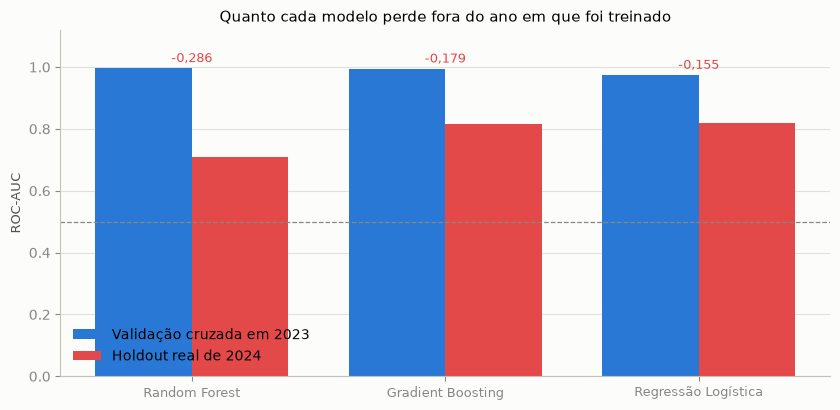

In [4]:
# ==== 4. FIGURA: O COLAPSO DA VALIDAÇÃO DENTRO DE UM ÚNICO ANO ====
plot = generalizacao[generalizacao["modelo"] != "Baseline (classe majoritária)"]
posicao = np.arange(len(plot))
largura = 0.38

fig, eixo = plt.subplots(figsize=(8.5, 4.2))
eixo.bar(posicao - largura / 2, plot["cv_2023"], largura,
         label="Validação cruzada em 2023", color=SERIE[0])
eixo.bar(posicao + largura / 2, plot["holdout_2024"], largura,
         label="Holdout real de 2024", color=NEGATIVO)
for i, (a, b) in enumerate(zip(plot["cv_2023"], plot["holdout_2024"])):
    eixo.annotate(f"-{a - b:.3f}".replace(".", ","), (i, max(a, b) + 0.02),
                  ha="center", fontsize=9, color=NEGATIVO)
eixo.axhline(0.5, color="#898781", linestyle="--", linewidth=0.9)
eixo.set(xticks=posicao, ylim=(0, 1.12), ylabel="ROC-AUC",
         title="Quanto cada modelo perde fora do ano em que foi treinado")
eixo.set_xticklabels(plot["modelo"], fontsize=9)
eixo.legend(loc="lower left")
limpar(eixo)
plt.tight_layout()
salvar(fig, "03_generalizacao_temporal", IMAGENS)
plt.show()

**Leitura - o achado metodológico do projeto.** A ordem dos modelos **se inverte**
entre as duas medições. O Random Forest, primeiro colocado em 2023 com 0,996, cai
para **0,711** em 2024 — perde 0,286 e fica abaixo de todos. A Regressão Logística,
última entre os três algoritmos na validação cruzada, é a **melhor no ciclo seguinte** (0,819) e a que menos
perde (0,155).

A causa é a natureza do alvo. `alvo = taxa >= meta_2025`, e as features contêm
`meta_2025` (um dos lados da desigualdade) e `media_portugues` (correlação 0,93 com
a taxa, o outro lado). Um modelo flexível **reconstrói a fronteira de decisão dentro
de um ano** — por isso o 0,996. Como a relação entre nota e taxa se desloca de 2023
para 2024, junto com a prevalência (18,1% → 43,4%), a fronteira memorizada não
transfere. A Regressão Logística, sendo aditiva e regularizada, não consegue
memorizar essa interação e por isso generaliza melhor.

**Consequência prática:** neste problema, validação cruzada dentro de um único
ciclo é uma medida enganosa de generalização. O critério que sustenta a escolha é
o desempenho no ciclo seguinte, e é ele que adotamos.

In [5]:
# ==== 5. OTIMIZAÇÃO DO MODELO ESCOLHIDO ====
# GridSearchCV com return_train_score: o gap treino-validação é a evidência
# direta de que a regularização está controlando o sobreajuste.
busca = GridSearchCV(
    construir_pipeline(),
    {"modelo__C": [0.01, 0.1, 1.0, 10.0]},
    scoring="f1", cv=particionador(), n_jobs=-1,
    refit=True, return_train_score=True,
)
busca.fit(X_treino, y_treino)
modelo_final = busca.best_estimator_

grade = pd.DataFrame(busca.cv_results_)[[
    "param_modelo__C", "mean_train_score", "mean_test_score", "std_test_score"
]].assign(gap=lambda d: d["mean_train_score"] - d["mean_test_score"])
print("Melhor configuracao:", busca.best_params_)
display(grade.round(4))

Melhor configuracao: {'modelo__C': 1.0}


,param_modelo__C,mean_train_score,mean_test_score,std_test_score,gap
0,0.01,0.7610,0.7617,0.0172,-0.0007
1,0.10,0.7921,0.7889,0.0128,0.0031
2,1.00,0.7995,0.7957,0.0076,0.0038
3,10.00,0.7989,0.7956,0.0088,0.0033


**Leitura.** O melhor `C` é **1,0**. O `gap` entre treino e validação nunca passa
de 0,004 em nenhum ponto da grade: a Regressão Logística não sobreajusta este
conjunto, e a regularização atua como salvaguarda contra a redundância territorial,
não como remédio para memorização. `C = 0,01` regulariza demais e perde 0,034 de F1.

,acuracia,precisao,recall,f1,roc_auc,pr_auc,acuracia_baseline
0,0.7173,0.8081,0.4569,0.5838,0.8191,0.7878,0.5661


,previsto: nao atingiu a meta,previsto: atingiu a meta
real: nao atingiu a meta,2778,252
real: atingiu a meta,1261,1061


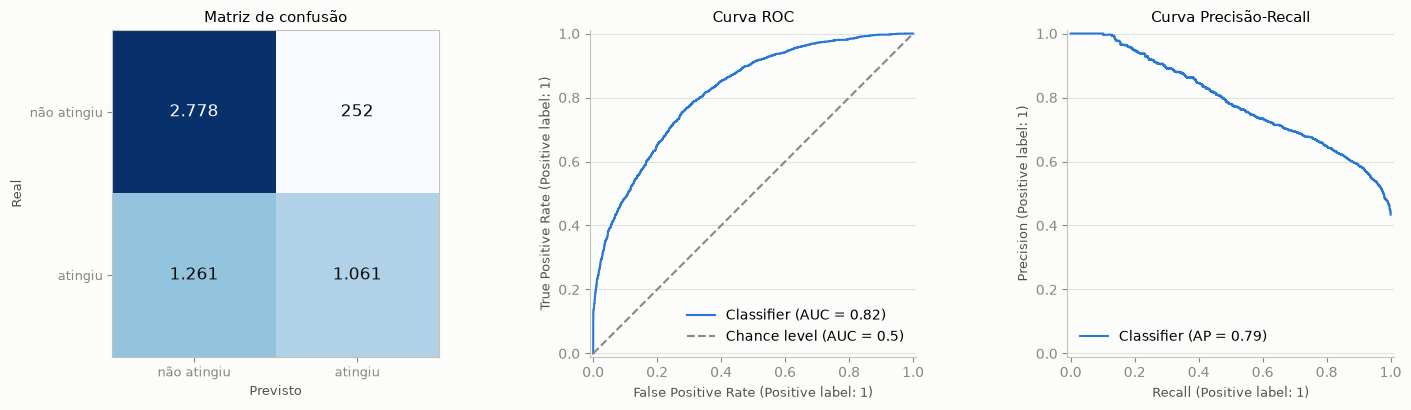

In [6]:
# ==== 6. AVALIAÇÃO FINAL NO HOLDOUT DE 2024 ====
y_pred = modelo_final.predict(X_teste)
y_prob = modelo_final.predict_proba(X_teste)[:, 1]
metricas = avaliar(y_teste, y_pred, y_prob)
display(pd.DataFrame([metricas]).round(4))
display(matriz_confusao(y_teste, y_pred))

fig, eixos = plt.subplots(1, 3, figsize=(15, 4.2))
mc = matriz_confusao(y_teste, y_pred).to_numpy()
eixos[0].imshow(mc, cmap="Blues")
for (i, j), valor in np.ndenumerate(mc):
    eixos[0].text(j, i, f"{valor:,}".replace(",", "."), ha="center", va="center",
                  color="white" if valor > mc.max() / 2 else "#0b0b0b", fontsize=12)
eixos[0].set(title="Matriz de confusão", xlabel="Previsto", ylabel="Real",
             xticks=[0, 1], yticks=[0, 1])
eixos[0].set_xticklabels(["não atingiu", "atingiu"], fontsize=9)
eixos[0].set_yticklabels(["não atingiu", "atingiu"], fontsize=9)
eixos[0].grid(False)
RocCurveDisplay.from_predictions(
    y_teste, y_prob, ax=eixos[1], curve_kwargs={"color": SERIE[0]},
    plot_chance_level=True, chance_level_kw={"color": "#898781"},
)
eixos[1].set_title("Curva ROC")
PrecisionRecallDisplay.from_predictions(
    y_teste, y_prob, ax=eixos[2], curve_kwargs={"color": SERIE[0]},
)
eixos[2].set_title("Curva Precisão-Recall")
for eixo in eixos[1:]:
    limpar(eixo)
plt.tight_layout()
salvar(fig, "03_avaliacao_modelo", IMAGENS)
plt.show()

,faixa,municipios,previsto,observado
0,0,536,0.000,0.047
1,1,535,0.000,0.105
2,2,535,0.002,0.193
3,3,535,0.007,0.288
4,4,535,0.023,0.372
5,5,535,0.070,0.488
6,6,535,0.210,0.550
7,7,535,0.488,0.594
8,8,535,0.807,0.764
9,9,536,0.983,0.938


Desvio medio de calibracao: 0.193


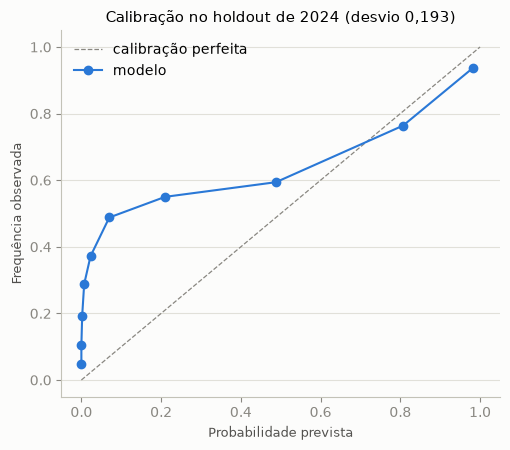

In [7]:
# ==== 7. CALIBRAÇÃO: A SAÍDA PODE SER LIDA COMO PROBABILIDADE? ====
faixas = curva_calibracao(y_teste, y_prob)
desvio = desvio_de_calibracao(y_teste, y_prob)
display(faixas)
print(f"Desvio medio de calibracao: {desvio:.3f}")

fig, eixo = plt.subplots(figsize=(5.2, 4.6))
eixo.plot([0, 1], [0, 1], "--", color="#898781", linewidth=0.9, label="calibração perfeita")
eixo.plot(faixas["previsto"], faixas["observado"], "o-", color=SERIE[0],
          label="modelo")
eixo.set(xlabel="Probabilidade prevista", ylabel="Frequência observada",
         title=f"Calibração no holdout de 2024 (desvio {desvio:.3f})".replace(".", ","))
eixo.legend()
limpar(eixo)
plt.tight_layout()
salvar(fig, "03_calibracao", IMAGENS)
plt.show()

**Leitura.** O desvio médio entre probabilidade prevista e frequência observada é
de **0,193**: o modelo subestima sistematicamente o atingimento em 2024. Isso é
esperado — ele foi treinado num ano em que 18,1% dos municípios atingiam a meta e
aplicado num ano em que 43,4% atingem. A **ordenação** dos municípios continua útil
(ROC-AUC 0,819), mas o valor absoluto da probabilidade não deve ser lido como
"chance real" sem recalibração. Esta é a justificativa quantitativa para o projeto
usar o escore como **ranking de triagem**, e não como número a ser publicado.

,variavel,coeficiente,importancia
0,media_portugues,5.416,5.416
1,sigla_uf_RN,2.570,2.570
2,sigla_uf_PA,2.161,2.161
3,sigla_uf_GO,1.970,1.970
4,sigla_uf_MS,-1.795,1.795
5,regiao_Sul,1.659,1.659
6,sigla_uf_TO,-1.639,1.639
7,sigla_uf_AM,1.448,1.448
8,sigla_uf_RO,-1.379,1.379
9,sigla_uf_ES,1.292,1.292


,variavel,queda_roc_auc,desvio
0,media_portugues,0.3815,0.0070
1,meta_2025,0.0059,0.0001
2,meta_uf_2025,-0.0016,0.0008
3,taxa_media_uf_loo,-0.0063,0.0017
4,sigla_uf,-0.0133,0.0014
5,regiao,-0.0276,0.0013


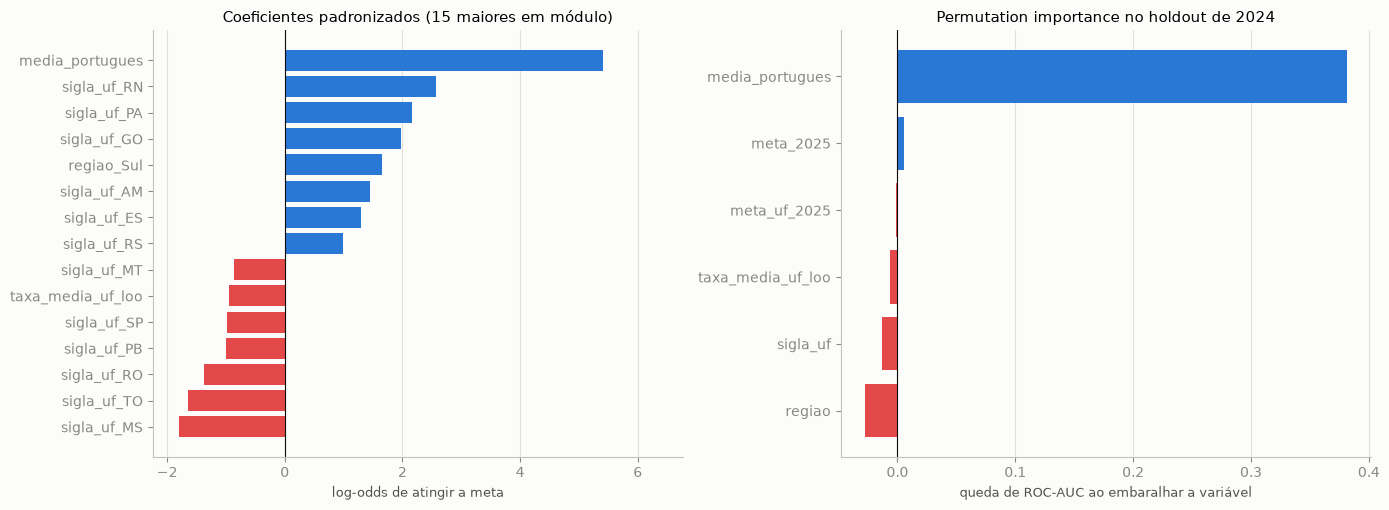

In [8]:
# ==== 8. INTERPRETABILIDADE I - FEATURE IMPORTANCE ====
# Duas lentes: coeficientes padronizados (nativa do modelo linear) e permutation
# importance (agnóstica, medida no holdout, sobre a coluna original).
coeficientes = importancia_nativa(modelo_final)
permutacao = importancia_por_permutacao(modelo_final, X_teste, y_teste)
display(coeficientes.head(15).round(3))
display(permutacao.round(4))

fig, eixos = plt.subplots(1, 2, figsize=(14, 5.2))
topo = coeficientes.head(15).sort_values("coeficiente")
cores = [POSITIVO if v > 0 else NEGATIVO for v in topo["coeficiente"]]
eixos[0].barh(topo["variavel"], topo["coeficiente"], color=cores)
eixos[0].axvline(0, color="#0b0b0b", linewidth=0.8)
eixos[0].set(title="Coeficientes padronizados (15 maiores em módulo)",
             xlabel="log-odds de atingir a meta")
eixos[0].set_xlim(topo["coeficiente"].min() * 1.25, topo["coeficiente"].max() * 1.25)

perm = permutacao.sort_values("queda_roc_auc")
cores = [POSITIVO if v > 0 else NEGATIVO for v in perm["queda_roc_auc"]]
eixos[1].barh(perm["variavel"], perm["queda_roc_auc"], color=cores)
eixos[1].axvline(0, color="#0b0b0b", linewidth=0.8)
eixos[1].set(title="Permutation importance no holdout de 2024",
             xlabel="queda de ROC-AUC ao embaralhar a variável")
for eixo in eixos:
    limpar(eixo, grade="x")
plt.tight_layout()
salvar(fig, "03_interpretabilidade_coeficientes", IMAGENS)
plt.show()

**Leitura.** As duas lentes contam histórias diferentes, e a diferença é informativa.

Pelos **coeficientes**, `media_portugues` domina (5,42), seguida por um bloco de
dummies estaduais — a leitura que o projeto vinha publicando.

Pela **permutation importance medida em 2024**, só `media_portugues` (0,382) e
`meta_2025` (0,006) contribuem de fato. `meta_uf_2025`, `taxa_media_uf_loo`,
`sigla_uf` e `regiao` têm importância **negativa**: embaralhá-las **melhora** o
ROC-AUC no ciclo seguinte. Ou seja, o bloco territorial ajusta um padrão regional
de 2023 que não se repete em 2024 e, na prática, atrapalha a generalização.

Isso explica a divergência regional relatada no notebook 04 (Nordeste e Sudeste com
risco previsto quase igual e resultados observados distintos) e reforça a decisão de
tratar o escore como triagem. Também é o argumento empírico para a evolução futura
"testar remoção de variáveis redundantes" — agora com um número por trás.

C:\Development\1IAST-Fase3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 5302 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5302 when initializing the masker.


Background dataset has 5302 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5302 when initializing the masker.


,variavel,shap_medio_abs
0,media_portugues,3.7994
1,taxa_media_uf_loo,0.8112
2,regiao_Sul,0.5350
3,meta_uf_2025,0.3565
4,regiao_Nordeste,0.3129
5,sigla_uf_RN,0.2180
6,regiao_Sudeste,0.1952
7,sigla_uf_SP,0.1675
8,sigla_uf_RS,0.1388
9,sigla_uf_GO,0.1260


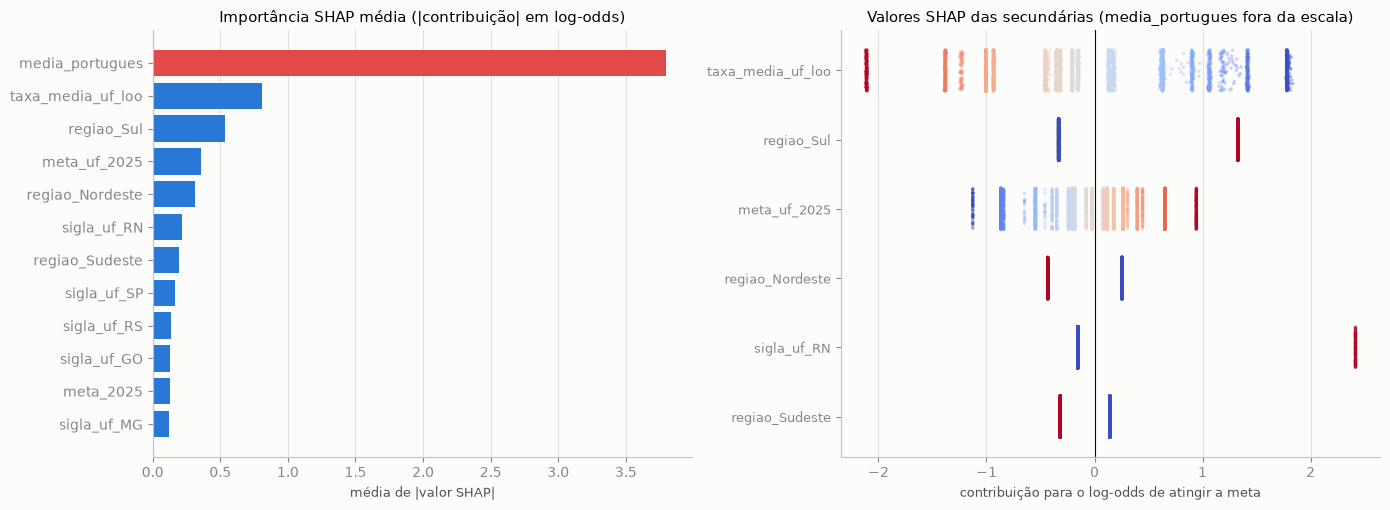

In [9]:
# ==== 9. INTERPRETABILIDADE II - SHAP VALUES ====
# O estimador final e linear, entao LinearExplainer devolve os valores exatos.
np.random.seed(SEMENTE)
shap_valores, X_transformado, nomes = valores_shap(modelo_final, X_treino, X_teste)
resumo_shap = importancia_shap(modelo_final, X_treino, X_teste)
display(resumo_shap.head(12).round(4))

fig, eixos = plt.subplots(1, 2, figsize=(14, 5.2))

# Esquerda: a hierarquia completa, onde a dominancia de media_portugues aparece.
topo = resumo_shap.head(12).sort_values("shap_medio_abs")
cores = [NEGATIVO if v == "media_portugues" else SERIE[0] for v in topo["variavel"]]
eixos[0].barh(topo["variavel"], topo["shap_medio_abs"], color=cores)
eixos[0].set(title="Importância SHAP média (|contribuição| em log-odds)",
             xlabel="média de |valor SHAP|")
limpar(eixos[0], grade="x")

# Direita: media_portugues fica de fora porque sua escala (ate 25 em log-odds)
# achataria todas as outras. A dominancia ja esta no painel da esquerda; aqui
# interessa a estrutura das variaveis secundarias.
secundarias = resumo_shap[resumo_shap["variavel"] != "media_portugues"].head(6)
ordem = secundarias["variavel"].tolist()[::-1]
for altura, nome in enumerate(ordem):
    idx = nomes.index(nome)
    valores = shap_valores[:, idx]
    ruido = np.random.uniform(-0.3, 0.3, len(valores))
    eixos[1].scatter(valores, altura + ruido, c=X_transformado[:, idx],
                     cmap="coolwarm", s=6, alpha=0.35, linewidths=0)
eixos[1].axvline(0, color="#0b0b0b", linewidth=0.8)
eixos[1].set(yticks=range(len(ordem)),
             title="Valores SHAP das secundárias (media_portugues fora da escala)",
             xlabel="contribuição para o log-odds de atingir a meta")
eixos[1].set_yticklabels(ordem, fontsize=9)
limpar(eixos[1], grade="x")
plt.tight_layout()
salvar(fig, "03_shap_summary", IMAGENS)
plt.show()

**Leitura.** O SHAP concorda com os coeficientes na ordem, mas mostra a **magnitude
real** da assimetria: `media_portugues` contribui em média **3,80** em log-odds,
enquanto a segunda colocada, `taxa_media_uf_loo`, contribui 0,81 — menos de um
quarto. Nenhuma dummy de UF passa de 0,22.

A dominância é tão grande que `media_portugues` precisou ficar fora do painel da
direita: seus valores individuais chegam a 25 em log-odds e achatariam todas as
outras variáveis contra o zero. Entre as secundárias, o padrão é o esperado de
variáveis binárias — dois grupos separados pelo zero, com deslocamento pequeno — e
`taxa_media_uf_loo` é a única contínua, com dispersão ordenada por valor.

**As três lentes convergem:** a nota de Português é o modelo. O restante ajusta
margens, e o bloco territorial ajusta margens que não sobrevivem à troca de ciclo.

In [10]:
# ==== 10. LIMIAR DE DECISÃO: COBERTURA CONTRA CAPACIDADE ====
# 0,5 é convenção de software. Quem prioriza município escolhe a cobertura.
cobertura = pd.DataFrame([
    limiar_por_recall(y_teste, y_prob, r) for r in (0.6, 0.7, 0.8, 0.9)
])
display(cobertura[["recall_desejado", "limiar", "municipios_sinalizados",
                   "precisao", "recall", "f1"]].round(4))

,recall_desejado,limiar,municipios_sinalizados,precisao,recall,f1
0,0.6,0.1939,1898,0.7345,0.6003,0.6607
1,0.7,0.0747,2344,0.6937,0.7003,0.6970
2,0.8,0.0251,2870,0.6474,0.8002,0.7157
3,0.9,0.0059,3561,0.5869,0.9001,0.7105


**Leitura.** A tabela traduz limiar em decisão de gestão. Para cobrir 90% dos
municípios que atingiram a meta seria preciso um limiar baixíssimo, sinalizando
quase todo o país. A leitura útil é a inversa, feita no notebook 04: quantos
municípios **em risco** cada corte captura, dado quantas equipes a secretaria tem.

In [11]:
# ==== 11. PERSISTÊNCIA DOS ARTEFATOS ====
reports = ROOT / "reports"
reports.mkdir(exist_ok=True)
joblib.dump(modelo_final, reports / "modelo_final.joblib")
holdout.round(6).to_csv(reports / "comparacao_modelos.csv", index=False)
cv_2023.round(6).to_csv(reports / "comparacao_modelos_cv2023.csv", index=False)
print("Artefatos gravados em", reports)
print("O model card completo e regenerado por: python -m src.modeling.model_card")

Artefatos gravados em C:\Development\1IAST-Fase3\reports
O model card completo e regenerado por: python -m src.modeling.model_card
